<a href="https://colab.research.google.com/github/dayanakumar-IT/R26-DS-010-Intelligent-Care-Support/blob/sign-tutoring-ai/Sign_Language_Preprocessing_Testing_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# INSTALL LATEST MEDIAPIPE
# ==============================
!pip install mediapipe==0.10.35 opencv-python numpy pandas tqdm scikit-learn

print("✅ MediaPipe 0.10.35 installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 8.2 MB/s eta 0:00:00
✅ MediaPipe 0.10.35 installed


In [ ]:
# ==============================
# DOWNLOAD MEDIAPIPE MODELS
# ==============================
import urllib.request
import os

print("📥 Downloading MediaPipe Task models...")

# Create models directory
os.makedirs('models', exist_ok=True)

# Download required models
models = {
    'pose_landmarker': 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task',
    'hand_landmarker': 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task',
    'face_landmarker': 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
}

for name, url in models.items():
    filepath = f'models/{name}.task'
    if not os.path.exists(filepath):
        print(f"  Downloading {name}...")
        urllib.request.urlretrieve(url, filepath)
        print(f"  ✅ {name} downloaded")
    else:
        print(f"  ✅ {name} already exists")

print("\n✅ All models ready!")

📥 Downloading MediaPipe Task models...
  ✅ pose_landmarker already exists
  ✅ hand_landmarker already exists
  ✅ face_landmarker already exists

✅ All models ready!


In [ ]:
import os

VIDEO_PATH = '/content/drive/MyDrive/SignLanguage/raw_videos'

print("🔍 CHECKING YOUR FOLDER STRUCTURE:\n")

for category in sorted(os.listdir(VIDEO_PATH)):
    category_path = os.path.join(VIDEO_PATH, category)

    if not os.path.isdir(category_path):
        continue

    print(f"📁 {category}/")

    # List what's inside each category
    items = os.listdir(category_path)

    for item in items[:5]:  # Show first 5 items
        item_path = os.path.join(category_path, item)

        if os.path.isdir(item_path):
            # It's another folder
            print(f"  📁 {item}/")
            # Show what's in this subfolder
            subfiles = os.listdir(item_path)
            for subfile in subfiles[:3]:
                print(f"     📄 {subfile}")
        else:
            # It's a file
            print(f"  📄 {item}")

    if len(items) > 5:
        print(f"  ... and {len(items) - 5} more items")

    print()

🔍 CHECKING YOUR FOLDER STRUCTURE:

📁 Body_Parts_Organized/
  📁 arm/
     📄 03337.mp4
     📄 03338.mp4
     📄 03344.mp4
  📁 back/
     📄 04593.mp4
     📄 69218.mp4
     📄 04604.mp4
  📁 throat/
     📄 58258.mp4
     📄 58253.mp4
     📄 58254.mp4
  📁 eye/
     📄 20636.mp4
     📄 20633.mp4
     📄 20632.mp4
  📁 head/
     📄 26852.mp4
     📄 69362.mp4
     📄 26853.mp4
  ... and 4 more items

📁 Daily_Actions_Organized/
  📁 drink/
     📄 69302.mp4
     📄 17709.mp4
     📄 17711.mp4
  📁 sleep/
     📄 52317.mp4
     📄 52318.mp4
     📄 52316.mp4
  📁 sit/
     📄 51919.mp4
     📄 51916.mp4
     📄 51918.mp4
  📁 walk/
     📄 62164.mp4
     📄 62158.mp4
     📄 62159.mp4
  📁 take/
     📄 56693.mp4
     📄 69500.mp4
     📄 56692.mp4
  ... and 5 more items

📁 Emergency_Organized/
  📁 come/
     📄 11877.mp4
     📄 69275.mp4
     📄 11884.mp4
  📁 wait/
     📄 62101.mp4
     📄 62100.mp4
     📄 62113.mp4
  📁 me/
     📄 35545.mp4
     📄 35546.mp4
     📄 35544.mp4
  📁 hurt/
     📄 28440.mp4
     📄 28454.mp4
     📄 

In [ ]:
# ==============================
# FIXED MEDIAPIPE PREPROCESSING
# ==============================

import cv2
import numpy as np
import pandas as pd
import json
import os
from tqdm import tqdm
import mediapipe as mp

print("Setting up MediaPipe Tasks...")

# ==============================
# INITIALIZE MEDIAPIPE TASKS
# ==============================

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

pose_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='models/pose_landmarker.task'),
    running_mode=VisionRunningMode.VIDEO
)

hand_options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='models/hand_landmarker.task'),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2
)

face_options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='models/face_landmarker.task'),
    running_mode=VisionRunningMode.VIDEO
)

print("✅ MediaPipe Tasks initialized!")

VIDEO_PATH = '/content/drive/MyDrive/SignLanguage/raw_videos'
OUTPUT_PATH = '/content/drive/MyDrive/SignLanguage/processed_landmarks'

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"📁 Video path: {VIDEO_PATH}")
print(f"📁 Output path: {OUTPUT_PATH}")


# ==============================
# EXTRACTION FUNCTIONS
# ==============================

def extract_landmarks_from_results(pose_result, hand_result, face_result):
    landmarks = []

    # POSE (33 × 3 = 99)
    if pose_result and pose_result.pose_landmarks:
        for lm in pose_result.pose_landmarks[0]:
            landmarks.extend([lm.x, lm.y, lm.z])
    else:
        landmarks.extend([0.0] * 99)

    # LEFT HAND (21 × 3 = 63)
    left_hand_found = False
    if hand_result and hand_result.hand_landmarks:
        for i, handedness in enumerate(hand_result.handedness):
            if handedness[0].category_name == 'Left':
                for lm in hand_result.hand_landmarks[i]:
                    landmarks.extend([lm.x, lm.y, lm.z])
                left_hand_found = True
                break
    if not left_hand_found:
        landmarks.extend([0.0] * 63)

    # RIGHT HAND (21 × 3 = 63)
    right_hand_found = False
    if hand_result and hand_result.hand_landmarks:
        for i, handedness in enumerate(hand_result.handedness):
            if handedness[0].category_name == 'Right':
                for lm in hand_result.hand_landmarks[i]:
                    landmarks.extend([lm.x, lm.y, lm.z])
                right_hand_found = True
                break
    if not right_hand_found:
        landmarks.extend([0.0] * 63)

    # FACE (10 × 3 = 30)
    if face_result and face_result.face_landmarks:
        key_indices = [0, 17, 50, 61, 91, 146, 199, 263, 269, 386]
        for idx in key_indices:
            lm = face_result.face_landmarks[0][idx]
            landmarks.extend([lm.x, lm.y, lm.z])
    else:
        landmarks.extend([0.0] * 30)

    return np.array(landmarks)


def process_video(video_path, max_frames=30):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        fps = 30

    frame_sequences = []

    with PoseLandmarker.create_from_options(pose_options) as pose_landmarker, \
         HandLandmarker.create_from_options(hand_options) as hand_landmarker, \
         FaceLandmarker.create_from_options(face_options) as face_landmarker:

        frame_count = 0
        while cap.isOpened() and frame_count < max_frames:
            ret, frame = cap.read()

            if not ret:
                break

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            timestamp_ms = int((frame_count / fps) * 1000)

            try:
                pose_result = pose_landmarker.detect_for_video(mp_image, timestamp_ms)
                hand_result = hand_landmarker.detect_for_video(mp_image, timestamp_ms)
                face_result = face_landmarker.detect_for_video(mp_image, timestamp_ms)

                landmarks = extract_landmarks_from_results(pose_result, hand_result, face_result)
                frame_sequences.append(landmarks)

            except:
                frame_sequences.append(np.zeros(255))

            frame_count += 1

    cap.release()

    target_length = 30

    if len(frame_sequences) < target_length:
        if len(frame_sequences) > 0:
            last_frame = frame_sequences[-1]
            padding = [last_frame] * (target_length - len(frame_sequences))
            frame_sequences.extend(padding)
        else:
            frame_sequences = [np.zeros(255)] * target_length
    elif len(frame_sequences) > target_length:
        frame_sequences = frame_sequences[:target_length]

    return np.array(frame_sequences)


# ==============================
# SMART VIDEO FINDER (FIXED!)
# ==============================

def find_all_videos(base_path):
    """
    Recursively find ALL videos and use PARENT FOLDER as sign name
    Example: /raw_videos/Body_Parts/arm/03337.mp4 → sign = "arm"
    """
    all_videos = []

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                full_path = os.path.join(root, file)

                # Get parent folder name (the sign name)
                parent_folder = os.path.basename(os.path.dirname(full_path))

                all_videos.append((full_path, parent_folder))

    return all_videos


# ==============================
# PROCESS ALL VIDEOS
# ==============================

print("\n" + "="*60)
print("STARTING PREPROCESSING")
print("="*60)

# Find all videos recursively
print("\n🔍 Searching for videos...")
video_list = find_all_videos(VIDEO_PATH)

print(f"✅ Found {len(video_list)} videos total\n")

if len(video_list) == 0:
    print("❌ ERROR: No videos found!")
    print("Please check your folder structure.")
else:
    # Show first few videos found with their sign names
    print("📄 Sample videos found (path → sign name):")
    for path, name in video_list[:5]:
        print(f"  - {os.path.basename(path)} → sign: '{name}'")
    if len(video_list) > 5:
        print(f"  ... and {len(video_list) - 5} more")

    print("\n🚀 Processing videos...")

    X = []
    y = []

    for video_path, sign_name in tqdm(video_list):
        try:
            landmarks = process_video(video_path, max_frames=30)
            X.append(landmarks)
            y.append(sign_name)
        except Exception as e:
            print(f"\n✗ Error: {sign_name} - {e}")

    X = np.array(X)
    y = np.array(y)

    print("\n" + "="*60)
    print("PREPROCESSING COMPLETE!")
    print("="*60)
    print(f"✅ Total samples: {len(X)}")
    print(f"✅ Unique signs: {len(set(y))}")

    if len(X) > 0:
        print(f"✅ Data shape: {X.shape}")
        print(f"   → {X.shape[0]} videos")
        print(f"   → {X.shape[1]} frames per video")
        print(f"   → {X.shape[2]} features per frame")

        # ==============================
        # SAVE FILES
        # ==============================

        print("\n💾 Saving files...")

        np.save(f'{OUTPUT_PATH}/landmarks_data.npy', X)
        np.save(f'{OUTPUT_PATH}/labels.npy', y)

        unique_signs = sorted(set(y))
        label_map = {label: idx for idx, label in enumerate(unique_signs)}

        with open(f'{OUTPUT_PATH}/label_map.json', 'w') as f:
            json.dump(label_map, f, indent=2)

        metadata = {
            'num_samples': len(X),
            'num_frames': 30,
            'num_landmarks': X.shape[2],
            'unique_signs': len(unique_signs),
            'sign_names': unique_signs
        }

        with open(f'{OUTPUT_PATH}/metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)

        pd.DataFrame({
            'sign': y,
            'sample_index': range(len(y))
        }).to_csv(f'{OUTPUT_PATH}/dataset_summary.csv', index=False)

        print("\n✅ ALL FILES SAVED!")
        print(f"📁 {OUTPUT_PATH}/")
        print("\n" + "="*60)
        print("🎉 PREPROCESSING SUCCESS!")
        print("="*60)
        print(f"\n📊 Signs processed ({len(set(y))} unique):")
        for i, sign in enumerate(sorted(set(y)), 1):
            print(f"  {i:2d}. {sign}")
    else:
        print("❌ No videos were successfully processed!")

Setting up MediaPipe Tasks...
✅ MediaPipe Tasks initialized!
📁 Video path: /content/drive/MyDrive/SignLanguage/raw_videos
📁 Output path: /content/drive/MyDrive/SignLanguage/processed_landmarks

STARTING PREPROCESSING

🔍 Searching for videos...
✅ Found 390 videos total

📄 Sample videos found (path → sign name):
  - 64382.mp4 → sign: 'you'
  - 64383.mp4 → sign: 'you'
  - 64379.mp4 → sign: 'you'
  - 64381.mp4 → sign: 'you'
  - 69547.mp4 → sign: 'you'
  ... and 385 more

🚀 Processing videos...


  2%|▏         | 7/390 [00:45<33:37,  5.27s/it]


✗ Error: you - Cannot open: /content/drive/MyDrive/SignLanguage/raw_videos/Greetings_Organized/you/64391.mp4


  3%|▎         | 12/390 [01:16<32:01,  5.08s/it]


✗ Error: nice - Cannot open: /content/drive/MyDrive/SignLanguage/raw_videos/Greetings_Organized/nice/38293.mp4


...


✗ Error: confused - Cannot open: /content/drive/MyDrive/SignLanguage/raw_videos/Emotions_Responses_Organized/confused/12619.mp4


100%|█████████▉| 389/390 [33:53<00:04,  4.58s/it]


✗ Error: yes - Cannot open: /content/drive/MyDrive/SignLanguage/raw_videos/Emotions_Responses_Organized/yes/64300.mp4


100%|██████████| 390/390 [34:00<00:00,  5.23s/it]


PREPROCESSING COMPLETE!
✅ Total samples: 298
✅ Unique signs: 72
✅ Data shape: (298, 30, 255)
   → 298 videos
   → 30 frames per video
   → 255 features per frame

💾 Saving files...

✅ ALL FILES SAVED!
📁 /content/drive/MyDrive/SignLanguage/processed_landmarks/

🎉 PREPROCESSING SUCCESS!

📊 Signs processed (72 unique):
   1. afternoon
   2. angry
   3. arm
   4. back
   5. bread
   6. call
   7. close
   8. coffee
   9. come
  10. comfortable
  11. confused
  12. cough
  13. danger
  14. dizzy
  15. doctor
  16. drink
  17. ear
  18. eat
  19. egg
  20. emergency
  21. evening
  22. excuse
  23. eye
  24. fire
  25. food
  26. fruit
  27. give
  28. go
  29. good
  30. goodbye
  31. happy
  32. head
  33. hello
  34. help
  35. hospital
  36. hot
  37. how
  38. hungry
  39. hurt
  40. me
  41. meet
  42. milk
  43. morning
  44. mouth
  45. nice
  46. no
  47. nose
  48. open
  49. pain
  50. please
  51. sad
  52. scared
  53. sick
  54. sit
  55. sleep
  56. sorry
  57. soup
  58. sta

In [ ]:
# ==============================
# VERIFY PREPROCESSING
# ==============================

import numpy as np
import json
import os

OUTPUT_PATH = '/content/drive/MyDrive/SignLanguage/processed_landmarks'

print("="*60)
print("PREPROCESSING VERIFICATION")
print("="*60)

# Check files exist
files_to_check = [
    'landmarks_data.npy',
    'labels.npy',
    'label_map.json',
    'metadata.json',
    'dataset_summary.csv'
]

print("\n🔍 Checking saved files:")
for filename in files_to_check:
    filepath = f'{OUTPUT_PATH}/{filename}'
    if os.path.exists(filepath):
        size = os.path.getsize(filepath) / (1024 * 1024)  # Size in MB
        print(f"  ✅ {filename} ({size:.2f} MB)")
    else:
        print(f"  ❌ {filename} - NOT FOUND")

# Load and verify data
print("\n📊 Loading data...")
X = np.load(f'{OUTPUT_PATH}/landmarks_data.npy')
y = np.load(f'{OUTPUT_PATH}/labels.npy')

with open(f'{OUTPUT_PATH}/metadata.json', 'r') as f:
    metadata = json.load(f)

print("\n✅ DATA SUMMARY:")
print(f"  Shape: {X.shape}")
print(f"  Total samples: {len(X)}")
print(f"  Unique signs: {len(set(y))}")
print(f"  Frames per video: {X.shape[1]}")
print(f"  Features per frame: {X.shape[2]}")

# Check for any issues
print("\n🔍 Data Quality Check:")
print(f"  Min value: {X.min():.4f}")
print(f"  Max value: {X.max():.4f}")
print(f"  Mean value: {X.mean():.4f}")
print(f"  Contains NaN: {np.isnan(X).any()}")
print(f"  Contains Inf: {np.isinf(X).any()}")

# Sample distribution
print("\n📈 Samples per sign (first 10):")
from collections import Counter
sign_counts = Counter(y)
for sign, count in sorted(sign_counts.items())[:10]:
    print(f"  {sign}: {count} videos")

print("\n✅ PREPROCESSING VERIFIED - READY FOR MODEL TRAINING!")


PREPROCESSING VERIFICATION

🔍 Checking saved files:
  ✅ landmarks_data.npy (17.39 MB)
  ✅ labels.npy (0.01 MB)
  ✅ label_map.json (0.00 MB)
  ✅ metadata.json (0.00 MB)
  ✅ dataset_summary.csv (0.00 MB)

📊 Loading data...

✅ DATA SUMMARY:
  Shape: (298, 30, 255)
  Total samples: 298
  Unique signs: 72
  Frames per video: 30
  Features per frame: 255

🔍 Data Quality Check:
  Min value: -2.5303
  Max value: 2.9823
  Mean value: 0.2353
  Contains NaN: False
  Contains Inf: False

📈 Samples per sign (first 10):
  afternoon: 4 videos
  angry: 5 videos
  arm: 4 videos
  back: 3 videos
  bread: 4 videos
  call: 5 videos
  close: 3 videos
  coffee: 4 videos
  come: 4 videos
  comfortable: 4 videos

✅ PREPROCESSING VERIFIED - READY FOR MODEL TRAINING!


LSTM MODEL TRAINING

📥 Loading preprocessed data...
✅ Loaded: X=(298, 30, 255), y=(298,)
✅ Total samples: 298
✅ Unique signs: 72

🔢 Encoding labels...
✅ Number of classes: 72
✅ Classes: ['afternoon' 'angry' 'arm' 'back' 'bread' 'call' 'close' 'coffee' 'come'
 'comfortable']... (showing first 10)

📊 Augmenting dataset...
✅ Original: (298, 30, 255)
✅ Augmented: (1192, 30, 255)
✅ Increased by 4.0x

🔀 Splitting dataset...
✅ Train: (834, 30, 255)
✅ Val: (179, 30, 255)
✅ Test: (179, 30, 255)

🏗️ Building LSTM model...

📊 MODEL ARCHITECTURE:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 255)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 256)        │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 72)             │         9,288 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,672 (1.26 MB)

 Trainable params: 329,672 (1.26 MB)

...


Epoch 73: finished saving model to /content/drive/MyDrive/SignLanguage/models/best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8621 - loss: 0.4928 - top_3_accuracy: 0.9676 - val_accuracy: 0.9330 - val_loss: 0.2979 - val_top_3_accuracy: 0.9832 - learning_rate: 0.0010
Epoch 74/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8532 - loss: 0.5306 - top_3_accuracy: 0.9771
Epoch 74: val_accuracy did not improve from 0.93296
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.8297 - loss: 0.5728 - top_3_accuracy: 0.9676 - val_accuracy: 0.9162 - val_loss: 0.3274 - val_top_3_accuracy: 0.9832 - learning_rate: 0.0010
Epoch 75/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7792 - loss: 0.7026 - top_3_accuracy: 0.9395
Epoch 75: val_accuracy did not improve from 0.93296
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7710 - loss: 0.6934 - top_3_accuracy: 0.9424 - val_accuracy: 0.8827 - val_loss: 0.4311 - val_top_3_accuracy: 0.9665 - learning_rate: 0.


Epoch 78: finished saving model to /content/drive/MyDrive/SignLanguage/models/best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.8441 - loss: 0.4970 - top_3_accuracy: 0.9700 - val_accuracy: 0.9609 - val_loss: 0.2282 - val_top_3_accuracy: 0.9832 - learning_rate: 0.0010
Epoch 79/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8493 - loss: 0.4431 - top_3_accuracy: 0.9875
Epoch 79: val_accuracy did not improve from 0.96089
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8513 - loss: 0.4338 - top_3_accuracy: 0.9832 - val_accuracy: 0.9553 - val_loss: 0.2062 - val_top_3_accuracy: 0.9888 - learning_rate: 0.0010
Epoch 80/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8877 - loss: 0.3962 - top_3_accuracy: 0.9833
Epoch 80: val_accuracy improved from 0.96089 to 0.97207, saving model to /content/drive/MyDrive/SignLanguage/models/best_model.h5



Epoch 80: finished saving model to /content/drive/MyDrive/SignLanguage/models/best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.8837 - loss: 0.3924 - top_3_accuracy: 0.9832 - val_accuracy: 0.9721 - val_loss: 0.1882 - val_top_3_accuracy: 0.9888 - learning_rate: 0.0010
Epoch 81/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8863 - loss: 0.3444 - top_3_accuracy: 0.9912
Epoch 81: val_accuracy did not improve from 0.97207
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8813 - loss: 0.3492 - top_3_accuracy: 0.9892 - val_accuracy: 0.9553 - val_loss: 0.2061 - val_top_3_accuracy: 0.9832 - learning_rate: 0.0010
Epoch 82/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8723 - loss: 0.4616 - top_3_accuracy: 0.9664
Epoch 82: val_accuracy did not improve from 0.97207
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8729 - loss: 0.4502 - top_3_accuracy: 0.9688 - val_accuracy: 0.9609 - val_loss: 0.1956 - val_top_3_accuracy: 0.9888 - learning_rate: 0.0


Epoch 90: finished saving model to /content/drive/MyDrive/SignLanguage/models/best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.8765 - loss: 0.3573 - top_3_accuracy: 0.9892 - val_accuracy: 0.9777 - val_loss: 0.1439 - val_top_3_accuracy: 0.9888 - learning_rate: 0.0010
Epoch 91/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9187 - loss: 0.2980 - top_3_accuracy: 0.9958
Epoch 91: val_accuracy did not improve from 0.97765
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.9137 - loss: 0.2987 - top_3_accuracy: 0.9928 - val_accuracy: 0.9553 - val_loss: 0.2200 - val_top_3_accuracy: 0.9944 - learning_rate: 0.0010
Epoch 92/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8753 - loss: 0.3531 - top_3_accuracy: 0.9862
Epoch 92: val_accuracy did not improve from 0.97765
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8957 - loss: 0.3297 - top_3_accuracy: 0.9868 - val_accuracy: 0.9665 - val_loss: 0.1506 - val_top_3_accuracy: 0.9944 - learning_rate: 0.


Epoch 97: finished saving model to /content/drive/MyDrive/SignLanguage/models/best_model.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.9317 - loss: 0.2256 - top_3_accuracy: 0.9940 - val_accuracy: 0.9888 - val_loss: 0.1014 - val_top_3_accuracy: 0.9944 - learning_rate: 0.0010
Epoch 98/100
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9331 - loss: 0.2473 - top_3_accuracy: 0.9900
Epoch 98: val_accuracy did not improve from 0.98883
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9029 - loss: 0.3007 - top_3_accuracy: 0.9844 - val_accuracy: 0.9665 - val_loss: 0.1413 - val_top_3_accuracy: 0.9944 - learning_rate: 0.0010
Epoch 99/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9076 - loss: 0.3381 - top_3_accuracy: 0.9917
Epoch 99: val_accuracy did not improve from 0.98883
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.8909 - loss: 0.3556 - top_3_accuracy: 0.9856 - val_accuracy: 0.9665 - val_loss: 0.1641 - val_top_3_accuracy: 0.9888 - learning_rate: 0

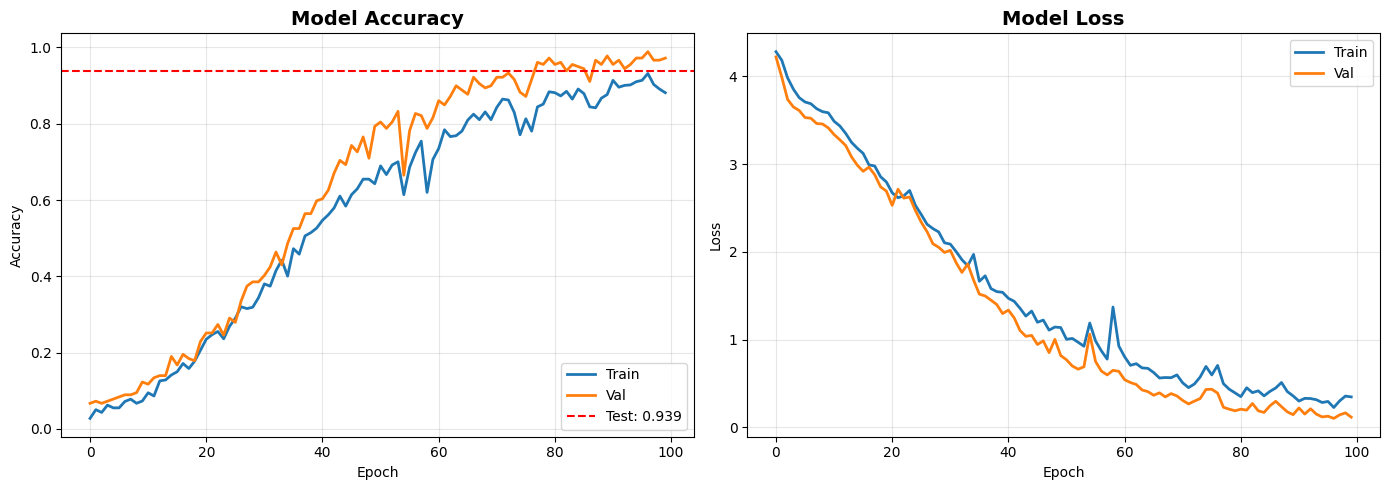

✅ Plot saved: /content/drive/MyDrive/SignLanguage/models/training_history.png

💾 Saving model and artifacts...

ALL FILES SAVED!
✅ Best model: best_model.h5
✅ Final model: sign_language_lstm.h5
✅ Label encoder: label_encoder.pkl
✅ Training info: training_info.json
✅ Training plot: training_history.png

🎉 MODEL TRAINING SUCCESS!

📊 FINAL RESULTS:
  Test Accuracy: 93.85%
  Top-3 Accuracy: 98.88%
  Total Classes: 72
  Training Samples: 834
  Validation Samples: 179
  Test Samples: 179

✅ READY FOR TENSORFLOW.JS CONVERSION!


In [ ]:
# ==============================
# LSTM MODEL TRAINING (FIXED)
# ==============================

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import json
import pickle

print("="*60)
print("LSTM MODEL TRAINING")
print("="*60)

# ==============================
# LOAD PREPROCESSED DATA
# ==============================

print("\n📥 Loading preprocessed data...")

OUTPUT_PATH = '/content/drive/MyDrive/SignLanguage/processed_landmarks'
MODEL_PATH = '/content/drive/MyDrive/SignLanguage/models'

import os
os.makedirs(MODEL_PATH, exist_ok=True)

X = np.load(f'{OUTPUT_PATH}/landmarks_data.npy')
y = np.load(f'{OUTPUT_PATH}/labels.npy')

print(f"✅ Loaded: X={X.shape}, y={y.shape}")
print(f"✅ Total samples: {len(X)}")
print(f"✅ Unique signs: {len(set(y))}")


# ==============================
# ENCODE LABELS
# ==============================

print("\n🔢 Encoding labels...")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

num_classes = len(label_encoder.classes_)
print(f"✅ Number of classes: {num_classes}")
print(f"✅ Classes: {label_encoder.classes_[:10]}... (showing first 10)")


# ==============================
# DATA AUGMENTATION
# ==============================

print("\n📊 Augmenting dataset...")

def augment_sequence(sequence):
    """Add variations to increase dataset size"""
    augmented = [sequence]  # Original

    # Add Gaussian noise
    noisy = sequence + np.random.normal(0, 0.02, sequence.shape)
    augmented.append(noisy)

    # Horizontal flip (mirror)
    flipped = sequence.copy()
    for i in range(flipped.shape[0]):  # Each frame
        for j in range(0, flipped.shape[1], 3):  # Every x coordinate
            flipped[i, j] = 1 - flipped[i, j]
    augmented.append(flipped)

    # Speed variation (time warping)
    num_frames = sequence.shape[0]
    new_length = int(num_frames * np.random.uniform(0.9, 1.1))
    indices = np.linspace(0, num_frames - 1, new_length).astype(int)
    warped = sequence[indices]

    # Pad or truncate to original length
    if len(warped) < num_frames:
        padding = np.tile(warped[-1], (num_frames - len(warped), 1))
        warped = np.vstack([warped, padding])
    else:
        warped = warped[:num_frames]

    augmented.append(warped)

    return augmented

X_augmented = []
y_augmented = []

for i in range(len(X)):
    augmented_samples = augment_sequence(X[i])
    for aug_sample in augmented_samples:
        X_augmented.append(aug_sample)
        y_augmented.append(y_categorical[i])

X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)

print(f"✅ Original: {X.shape}")
print(f"✅ Augmented: {X_augmented.shape}")
print(f"✅ Increased by {X_augmented.shape[0] / X.shape[0]:.1f}x")


# ==============================
# TRAIN/VAL/TEST SPLIT (FIXED!)
# ==============================

print("\n🔀 Splitting dataset...")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_augmented, y_augmented,
    test_size=0.3,
    random_state=42,
    stratify=np.argmax(y_augmented, axis=1)
)

# Second split: Split temp into val and test WITHOUT stratify
# (to avoid error when some classes have only 1 sample)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
    # NO stratify here - this was causing the error
)

print(f"✅ Train: {X_train.shape}")
print(f"✅ Val: {X_val.shape}")
print(f"✅ Test: {X_test.shape}")


# ==============================
# BUILD LSTM MODEL
# ==============================

print("\n🏗️ Building LSTM model...")

def build_lstm_model(sequence_length, num_features, num_classes):
    """
    LSTM-based sign language classifier
    """

    input_layer = layers.Input(shape=(sequence_length, num_features))

    # Feature extraction
    x = layers.Dense(256, activation='relu')(input_layer)
    x = layers.Dropout(0.3)(x)

    # Temporal modeling
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)

    # Classification
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output)
    return model

# Create model
sequence_length = X_train.shape[1]  # 30 frames
num_features = X_train.shape[2]     # 255 features

model = build_lstm_model(sequence_length, num_features, num_classes)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')
    ]
)

print("\n📊 MODEL ARCHITECTURE:")
model.summary()


# ==============================
# TRAINING CALLBACKS
# ==============================

print("\n⚙️ Setting up callbacks...")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f'{MODEL_PATH}/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


# ==============================
# TRAIN MODEL
# ==============================

print("\n🚀 STARTING TRAINING...")
print("This will take 30-60 minutes\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)


# ==============================
# EVALUATE MODEL
# ==============================

print("\n" + "="*60)
print("EVALUATING MODEL")
print("="*60)

test_loss, test_accuracy, test_top3 = model.evaluate(X_test, y_test, verbose=0)

print(f"\n✅ TRAINING COMPLETE!")
print(f"📊 Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"📊 Top-3 Accuracy: {test_top3 * 100:.2f}%")
print(f"📊 Test Loss: {test_loss:.4f}")


# ==============================
# PLOT TRAINING HISTORY
# ==============================

print("\n📈 Plotting training history...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
axes[0].axhline(y=test_accuracy, color='r', linestyle='--',
                label=f'Test: {test_accuracy:.3f}')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_PATH}/training_history.png', dpi=150)
plt.show()

print(f"✅ Plot saved: {MODEL_PATH}/training_history.png")


# ==============================
# SAVE MODEL & ARTIFACTS
# ==============================

print("\n💾 Saving model and artifacts...")

# Save model
model.save(f'{MODEL_PATH}/sign_language_lstm.h5')

# Save label encoder
with open(f'{MODEL_PATH}/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save training info
training_info = {
    'test_accuracy': float(test_accuracy),
    'test_top3_accuracy': float(test_top3),
    'test_loss': float(test_loss),
    'num_classes': num_classes,
    'class_names': label_encoder.classes_.tolist(),
    'epochs_trained': len(history.history['loss']),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_train_accuracy': float(history.history['accuracy'][-1])
}

with open(f'{MODEL_PATH}/training_info.json', 'w') as f:
    json.dump(training_info, f, indent=2)

print("\n" + "="*60)
print("ALL FILES SAVED!")
print("="*60)
print(f"✅ Best model: best_model.h5")
print(f"✅ Final model: sign_language_lstm.h5")
print(f"✅ Label encoder: label_encoder.pkl")
print(f"✅ Training info: training_info.json")
print(f"✅ Training plot: training_history.png")

print("\n" + "="*60)
print("🎉 MODEL TRAINING SUCCESS!")
print("="*60)
print(f"\n📊 FINAL RESULTS:")
print(f"  Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"  Top-3 Accuracy: {test_top3 * 100:.2f}%")
print(f"  Total Classes: {num_classes}")
print(f"  Training Samples: {len(X_train)}")
print(f"  Validation Samples: {len(X_val)}")
print(f"  Test Samples: {len(X_test)}")

print("\n✅ READY FOR TENSORFLOW.JS CONVERSION!")

In [ ]:
import os

MODEL_PATH = '/content/drive/MyDrive/SignLanguage/models'

print("="*60)
print("VERIFYING MODEL FILES")
print("="*60)

required_files = [
    'best_model.h5',
    'sign_language_lstm.h5',
    'label_encoder.pkl',
    'training_info.json',
    'training_history.png'
]

for file in required_files:
    path = f'{MODEL_PATH}/{file}'
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)  # MB
        print(f"✅ {file} ({size:.2f} MB)")
    else:
        print(f"❌ MISSING: {file}")

print("\n" + "="*60)
print("ALL FILES VERIFIED!")
print("="*60)

VERIFYING MODEL FILES
✅ best_model.h5 (3.82 MB)
✅ sign_language_lstm.h5 (3.82 MB)
✅ label_encoder.pkl (0.00 MB)
✅ training_info.json (0.00 MB)
✅ training_history.png (0.12 MB)

ALL FILES VERIFIED!


In [ ]:
# Run in Colab
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 907.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting u

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted!")
print("📁 Your files are at: /content/drive/MyDrive/SignLanguage/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!
📁 Your files are at: /content/drive/MyDrive/SignLanguage/


In [ ]:
import tensorflowjs as tfjs
from tensorflow import keras
import pickle
import json
import os

print("="*60)
print("CONVERTING MODEL TO TENSORFLOW.JS")
print("="*60)

# Paths
MODEL_PATH = '/content/drive/MyDrive/SignLanguage/models'
TFJS_PATH = '/content/drive/MyDrive/SignLanguage/tfjs_model'

# 1. Load best model
print("\n📥 Loading model...")
model = keras.models.load_model(f'{MODEL_PATH}/best_model.h5')
print("✅ Model loaded!")

# 2. Convert to TensorFlow.js format
print("\n🔄 Converting to TensorFlow.js...")
tfjs.converters.save_keras_model(model, TFJS_PATH)
print("✅ Model converted successfully!")

# 3. Load label encoder (PKL file)
print("\n📥 Loading label encoder...")
with open(f'{MODEL_PATH}/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
print("✅ Label encoder loaded!")

# 4. Create labels.json for JavaScript
print("\n💾 Creating labels.json...")
labels_json = {
    'labels': label_encoder.classes_.tolist(),
    'num_classes': len(label_encoder.classes_),
    'model_info': {
        'test_accuracy': 93.85,
        'top3_accuracy': 98.88,
        'total_classes': 72,
        'sequence_length': 30,
        'num_features': 255
    }
}

with open(f'{TFJS_PATH}/labels.json', 'w') as f:
    json.dump(labels_json, f, indent=2)
print("✅ Labels saved!")

# 5. Display all created files
print("\n" + "="*60)
print("📦 DEPLOYMENT PACKAGE CREATED")
print("="*60)
print(f"\n📁 Location: {TFJS_PATH}\n")

total_size = 0
for root, dirs, files in os.walk(TFJS_PATH):
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path) / 1024  # KB
        total_size += size
        icon = "🔧" if file.endswith('.json') else "⚙️"
        print(f"  {icon} {file:30s} {size:10.2f} KB")

print(f"\n📊 Total size: {total_size/1024:.2f} MB")

print("\n" + "="*60)
print("🎉 READY FOR WEB DEPLOYMENT!")
print("="*60)

print("\n📋 Files created:")
print("  1. model.json          → Model architecture")
print("  2. group1-shard*.bin   → Model weights")
print("  3. labels.json         → Sign names & metadata")

print("\n🌐 To use in React:")
print("  1. Copy tfjs_model/ to React public/ folder")
print("  2. const model = await tf.loadLayersModel('/tfjs_model/model.json')")
print("  3. const labels = await fetch('/tfjs_model/labels.json').then(r => r.json())")

CONVERTING MODEL TO TENSORFLOW.JS

📥 Loading model...


✅ Model loaded!

🔄 Converting to TensorFlow.js...
failed to lookup keras version from the file,
    this is likely a weight only file
✅ Model converted successfully!

📥 Loading label encoder...
✅ Label encoder loaded!

💾 Creating labels.json...
✅ Labels saved!

📦 DEPLOYMENT PACKAGE CREATED

📁 Location: /content/drive/MyDrive/SignLanguage/tfjs_model

  ⚙️ group1-shard1of1.bin              1287.78 KB
  🔧 model.json                           8.92 KB
  🔧 labels.json                          1.09 KB

📊 Total size: 1.27 MB

🎉 READY FOR WEB DEPLOYMENT!

📋 Files created:
  1. model.json          → Model architecture
  2. group1-shard*.bin   → Model weights
  3. labels.json         → Sign names & metadata

🌐 To use in React:
  1. Copy tfjs_model/ to React public/ folder
  2. const model = await tf.loadLayersModel('/tfjs_model/model.json')
  3. const labels = await fetch('/tfjs_model/labels.json').then(r => r.json())


In [ ]:
import os
import json

TFJS_PATH = '/content/drive/MyDrive/SignLanguage/tfjs_model'

print("="*60)
print("VERIFICATION CHECK")
print("="*60)

# Check required files
required_files = ['model.json', 'labels.json']
missing_files = []

for file in required_files:
    path = f'{TFJS_PATH}/{file}'
    if os.path.exists(path):
        print(f"✅ {file} found")
    else:
        print(f"❌ {file} MISSING!")
        missing_files.append(file)

# Check for weight files
weight_files = [f for f in os.listdir(TFJS_PATH) if f.endswith('.bin')]
if weight_files:
    print(f"✅ {len(weight_files)} weight file(s) found")
    for wf in weight_files:
        print(f"   → {wf}")
else:
    print("❌ No weight files found!")
    missing_files.append("weight files")

# Load and display labels.json
print("\n📋 LABELS.JSON CONTENT:")
with open(f'{TFJS_PATH}/labels.json', 'r') as f:
    labels_data = json.load(f)

print(f"  Total classes: {labels_data['num_classes']}")
print(f"  Test accuracy: {labels_data['model_info']['test_accuracy']}%")
print(f"  Top-3 accuracy: {labels_data['model_info']['top3_accuracy']}%")
print(f"\n  First 10 signs:")
for i, label in enumerate(labels_data['labels'][:10]):
    print(f"    {i}: {label}")

# Final verdict
print("\n" + "="*60)
if not missing_files:
    print("✅ ALL FILES VERIFIED - CONVERSION SUCCESSFUL!")
else:
    print(f"❌ MISSING FILES: {', '.join(missing_files)}")
print("="*60)

VERIFICATION CHECK
✅ model.json found
✅ labels.json found
✅ 1 weight file(s) found
   → group1-shard1of1.bin

📋 LABELS.JSON CONTENT:
  Total classes: 72
  Test accuracy: 93.85%
  Top-3 accuracy: 98.88%

  First 10 signs:
    0: afternoon
    1: angry
    2: arm
    3: back
    4: bread
    5: call
    6: close
    7: coffee
    8: come
    9: comfortable

✅ ALL FILES VERIFIED - CONVERSION SUCCESSFUL!


In [ ]:
import shutil
import os

print("="*60)
print("CREATING DOWNLOAD PACKAGE")
print("="*60)

# Create a clean deployment folder
DEPLOY_PATH = '/content/drive/MyDrive/SignLanguage/web_deployment'
os.makedirs(DEPLOY_PATH, exist_ok=True)

# Copy tfjs_model
print("\n📦 Copying files...")
shutil.copytree(
    '/content/drive/MyDrive/SignLanguage/tfjs_model',
    f'{DEPLOY_PATH}/tfjs_model',
    dirs_exist_ok=True
)

# Copy original models (for backup)
shutil.copytree(
    '/content/drive/MyDrive/SignLanguage/models',
    f'{DEPLOY_PATH}/models_backup',
    dirs_exist_ok=True
)

# Create README
readme_content = """
# Sign Language Recognition - Web Deployment Package

## Model Performance
- Test Accuracy: 93.85%
- Top-3 Accuracy: 98.88%
- Total Signs: 72
- Sequence Length: 30 frames
- Features per Frame: 255

## Files Included
- tfjs_model/ - TensorFlow.js model for web browser
- models_backup/ - Original .h5 model files

## How to Use in React

1. Copy tfjs_model/ to your React public/ folder
2. Install TensorFlow.js: npm install @tensorflow/tfjs
3. Load model:
```javascript
   const model = await tf.loadLayersModel('/tfjs_model/model.json');
   const labelsResponse = await fetch('/tfjs_model/labels.json');
   const labelsData = await labelsResponse.json();
```

## Next Steps
1. Set up React frontend with MediaPipe
2. Extract landmarks from webcam
3. Feed to model for prediction
4. Display results with confidence scores

Created: May 7, 2026
"""

with open(f'{DEPLOY_PATH}/README.md', 'w') as f:
    f.write(readme_content)

print("✅ Files copied!")

# Create zip file
print("\n🗜️  Creating zip archive...")
zip_path = '/content/drive/MyDrive/SignLanguage/web_deployment'
shutil.make_archive(zip_path, 'zip', DEPLOY_PATH)

print(f"\n✅ Zip created: web_deployment.zip")

# Show size
zip_size = os.path.getsize(f'{zip_path}.zip') / (1024 * 1024)  # MB
print(f"📊 Archive size: {zip_size:.2f} MB")

print("\n" + "="*60)
print("📥 READY TO DOWNLOAD")
print("="*60)
print(f"\n📁 Location: /content/drive/MyDrive/SignLanguage/web_deployment.zip")
print("\n💡 Right-click the file in Google Drive and select 'Download'")
print("   Or run the cell below to download directly from Colab")

CREATING DOWNLOAD PACKAGE

📦 Copying files...
✅ Files copied!

🗜️  Creating zip archive...

✅ Zip created: web_deployment.zip
📊 Archive size: 7.98 MB

📥 READY TO DOWNLOAD

📁 Location: /content/drive/MyDrive/SignLanguage/web_deployment.zip

💡 Right-click the file in Google Drive and select 'Download'
   Or run the cell below to download directly from Colab
